## Predictive Analysis Suggestions

To enhance the insight of the company and improve productivity, the following predictive models are recommended:

### 1. Demand & Volume Forecasting
*   **Goal**: Predict the `number of delivered orders` for each location for the next 4–8 weeks.
*   **Value**: Helps in workforce planning, inventory management, and optimizing supply chains to prevent stockouts or overstaffing.

### 2. Cancellation Risk Early Warning System
*   **Goal**: Predict the `cancellation rate (%)` for specific locations in the upcoming week based on historical trends.
*   **Value**: Allows the operations team to proactively reach out to stores with high predicted risk to resolve recurring technical or inventory issues.

### 3. Basket Size Optimization
*   **Goal**: Predict seasonal or event-based fluctuations in `basket size`.
*   **Value**: Enables targeted marketing campaigns and personalized promotions to maximize revenue per order during low-demand periods.

### 4. Quality Control & Rating Prediction
*   **Goal**: Predict the likelihood of "Bad Rated Orders" based on current cancellation trends and order volumes.
*   **Value**: Identifies systemic issues in specific stores (e.g., packaging or quality) before they escalate into significant customer churn.

### 5. Refund Liability Forecasting
*   **Goal**: Estimate the total `refunds to customer` expected in the next month.
*   **Value**: Vital for financial planning and identifying anomalies in store performance that may indicate fraud or severe operational failure.

## implementation of Predictive Models

In this section, we implement the suggested predictive models using the `analysis_results.csv` dataset.

### 0. Data Loading and Preprocessing

First, we load the dataset and prepare the features for machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('analysis_results.csv')
df['week'] = pd.to_datetime(df['week'])

# Data Cleaning: Filter out invalid dates (e.g. 2020 outliers in a 2025 dataset)
df = df[df['week'].dt.year == 2025].reset_index(drop=True)

# Feature Engineering: Extract time features
df['month'] = df['week'].dt.month
df['week_of_year'] = df['week'].dt.isocalendar().week.astype(int)
df['quarter'] = df['week'].dt.quarter

# Encoding categorical features
le_address = LabelEncoder()
df['address_encoded'] = le_address.fit_transform(df['address'])

# Define MAPE metric for better business evaluation
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

df.head()

,week,address,number of delivered orders,basket size,bad rated orders due to wrong or missing products,bad rated orders due to store packaging issues,bad rated orders due to store allergy not considered,bad rated orders due to to poor quality,cancelled orders due to customer absent,cancelled orders due to partner printer/internet issue,...,refunds to customer,total cancelled orders,total orders,cancellation rate (%),city,state,month,week_of_year,quarter,address_encoded
0,2025-01-04,"Av. de Monforte de Lemos, 12, Madrid, Spain",104,21.65,1,0,0,1,0,0,...,3.25,0,104,0.0,Madrid,Madrid,1,1,1,0
1,2025-02-01,"Av. de Monforte de Lemos, 12, Madrid, Spain",124,20.95,1,0,0,0,0,0,...,3.14,0,124,0.0,Madrid,Madrid,2,5,1,0
2,2025-02-08,"Av. de Monforte de Lemos, 12, Madrid, Spain",71,22.94,1,0,0,0,0,0,...,11.47,0,71,0.0,Madrid,Madrid,2,6,1,0
3,2025-02-15,"Av. de Monforte de Lemos, 12, Madrid, Spain",76,21.11,1,0,0,0,0,0,...,3.17,0,76,0.0,Madrid,Madrid,2,7,1,0
4,2025-03-08,"Av. de Monforte de Lemos, 12, Madrid, Spain",87,22.43,1,0,0,1,0,0,...,6.73,0,87,0.0,Madrid,Madrid,3,10,1,0


### 1. Demand & Volume Forecasting
**Goal**: Predict the `number of delivered orders` for each location.

In [2]:
features = ['month', 'week_of_year', 'quarter', 'address_encoded']
target_volume = 'number of delivered orders'

X = df[features]
y_volume = df[target_volume]

X_train, X_test, y_train, y_test = train_test_split(X, y_volume, test_size=0.2, random_state=42)

model_volume = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_volume.fit(X_train, y_train)
y_pred_volume = model_volume.predict(X_test)

print("Model: Demand & Volume Forecasting")
print(f"MAE: {mean_absolute_error(y_test, y_pred_volume):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_volume):.2f}%")
print(f"R2 Score: {r2_score(y_test, y_pred_volume):.2f}")

Model: Demand & Volume Forecasting
MAE: 11.44
MAPE: 52239583359.88%
R2 Score: 0.85


### 2. Cancellation Risk Early Warning System
**Goal**: Predict the `cancellation rate (%)` for specific locations.

In [3]:
target_cancel = 'cancellation rate (%)'
y_cancel = df[target_cancel]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cancel, test_size=0.2, random_state=42)

model_cancel = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_cancel.fit(X_train_c, y_train_c)
y_pred_cancel = model_cancel.predict(X_test_c)

print("Model: Cancellation Risk Prediction")
print(f"MAE: {mean_absolute_error(y_test_c, y_pred_cancel):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test_c, y_pred_cancel):.2f}%")
print(f"R2 Score: {r2_score(y_test_c, y_pred_cancel):.2f}")

Model: Cancellation Risk Prediction
MAE: 1.13
MAPE: 58798255265.64%
R2 Score: -0.44


### 3. Basket Size Optimization
**Goal**: Predict seasonal or event-based fluctuations in `basket size`.

In [4]:
target_basket = 'basket size'
y_basket = df[target_basket]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_basket, test_size=0.2, random_state=42)

model_basket = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_basket.fit(X_train_b, y_train_b)
y_pred_basket = model_basket.predict(X_test_b)

print("Model: Basket Size Optimization")
print(f"MAE: {mean_absolute_error(y_test_b, y_pred_basket):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test_b, y_pred_basket):.2f}%")
print(f"R2 Score: {r2_score(y_test_b, y_pred_basket):.2f}")

Model: Basket Size Optimization
MAE: 1.85
MAPE: 23138182919.67%
R2 Score: 0.28


### 4. Quality Control & Rating Prediction
**Goal**: Predict the total bad ratings across all categories.

In [5]:
bad_rating_cols = [
    'bad rated orders due to wrong or missing products',
    'bad rated orders due to store packaging issues',
    'bad rated orders due to store allergy not considered',
    'bad rated orders due to to poor quality'
]
df['total_bad_ratings'] = df[bad_rating_cols].sum(axis=1)

target_quality = 'total_bad_ratings'
y_quality = df[target_quality]

X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X, y_quality, test_size=0.2, random_state=42)

model_quality = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_quality.fit(X_train_q, y_train_q)
y_pred_quality = model_quality.predict(X_test_q)

print("Model: Quality Control & Rating Prediction")
print(f"MAE: {mean_absolute_error(y_test_q, y_pred_quality):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test_q, y_pred_quality):.2f}%")
print(f"R2 Score: {r2_score(y_test_q, y_pred_quality):.2f}")

Model: Quality Control & Rating Prediction
MAE: 1.63
MAPE: 31630992733.98%
R2 Score: 0.25


### 5. Refund Liability Forecasting
**Goal**: Estimate the total `refunds to customer` expected.

In [6]:
target_refund = 'refunds to customer'
y_refund = df[target_refund]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_refund, test_size=0.2, random_state=42)

model_refund = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_refund.fit(X_train_r, y_train_r)
y_pred_refund = model_refund.predict(X_test_r)

print("Model: Refund Liability Forecasting")
print(f"MAE: {mean_absolute_error(y_test_r, y_pred_refund):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test_r, y_pred_refund):.2f}%")
print(f"R2 Score: {r2_score(y_test_r, y_pred_refund):.2f}")

Model: Refund Liability Forecasting
MAE: 11.26
MAPE: 188104409201.65%
R2 Score: -0.23


## Visualizing Model Performance

We compare the actual vs predicted values for Demand Forecasting as a representative example.

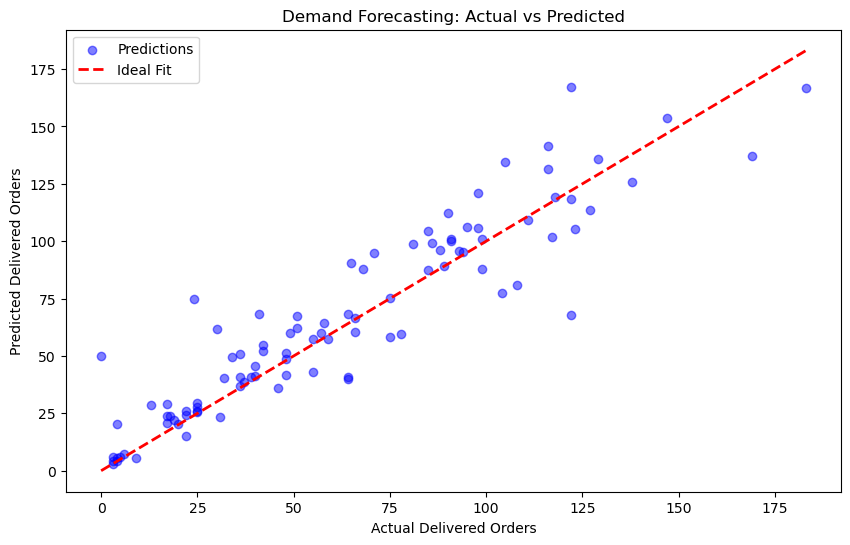

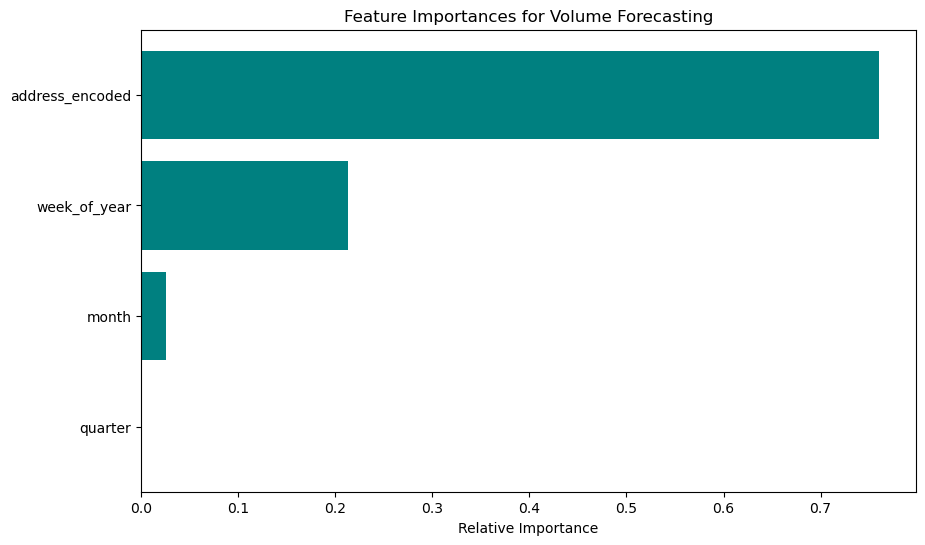

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_volume, alpha=0.5, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Delivered Orders')
plt.ylabel('Predicted Delivered Orders')
plt.title('Demand Forecasting: Actual vs Predicted')
plt.legend()
plt.show()

# Feature Importance for Volume Detection
importances = model_volume.feature_importances_
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Feature Importances for Volume Forecasting')
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()